In [1]:
import yaml
import pandas as pd
from pathlib import Path

BASE_DIR = Path(r"C:\Users\santh\Documents\Python\data")
OUTPUT_DIR = BASE_DIR / "output_csv"
OUTPUT_DIR.mkdir(exist_ok=True)

all_data = []
for yaml_file in BASE_DIR.rglob("*.yaml"):
    with open(yaml_file, "r", encoding="utf-8") as f:
        records = yaml.safe_load(f)
        if records:
            all_data.extend(records)

df = pd.DataFrame(all_data)

if 'Ticker' in df.columns:
    df.rename(columns={"Ticker": "symbol"}, inplace=True)
elif 'symbol' not in df.columns:
    df['symbol'] = 'UNKNOWN'

df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year
df.sort_values(by=["symbol", "date"], inplace=True)

for symbol, group in df.groupby("symbol", sort=False):
    output_df = group.drop(columns=["year"])
    output_df.to_csv(OUTPUT_DIR / f"{symbol}.csv", index=False)


In [3]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path(r"C:\Users\santh\Documents\Python\data")
OUTPUT_DIR = BASE_DIR / "output_csv"
VOLATILITY_FILE = BASE_DIR / "stock_volatility_report.csv"

def generate_volatility_csv():
    csv_files = list(OUTPUT_DIR.glob("*.csv"))
    dfs = []
    for file in csv_files:
        temp = pd.read_csv(file)
        temp["Symbol"] = file.stem
        dfs.append(temp)

    df = pd.concat(dfs, ignore_index=True)

    df["date"] = pd.to_datetime(df["date"])
    df.sort_values(["Symbol", "date"], inplace=True)
    df = df.groupby(["date", "Symbol"], as_index=False).agg({"close": "last"})

    df["Daily_Return"] = df.groupby("Symbol")["close"].pct_change()
    volatility_df = df.groupby("Symbol")["Daily_Return"].std().reset_index()
    volatility_df.rename(columns={"Daily_Return": "Volatility"}, inplace=True)
    volatility_df.dropna(inplace=True)

    volatility_df.to_csv(VOLATILITY_FILE, index=False)

if __name__ == "__main__":
    generate_volatility_csv()


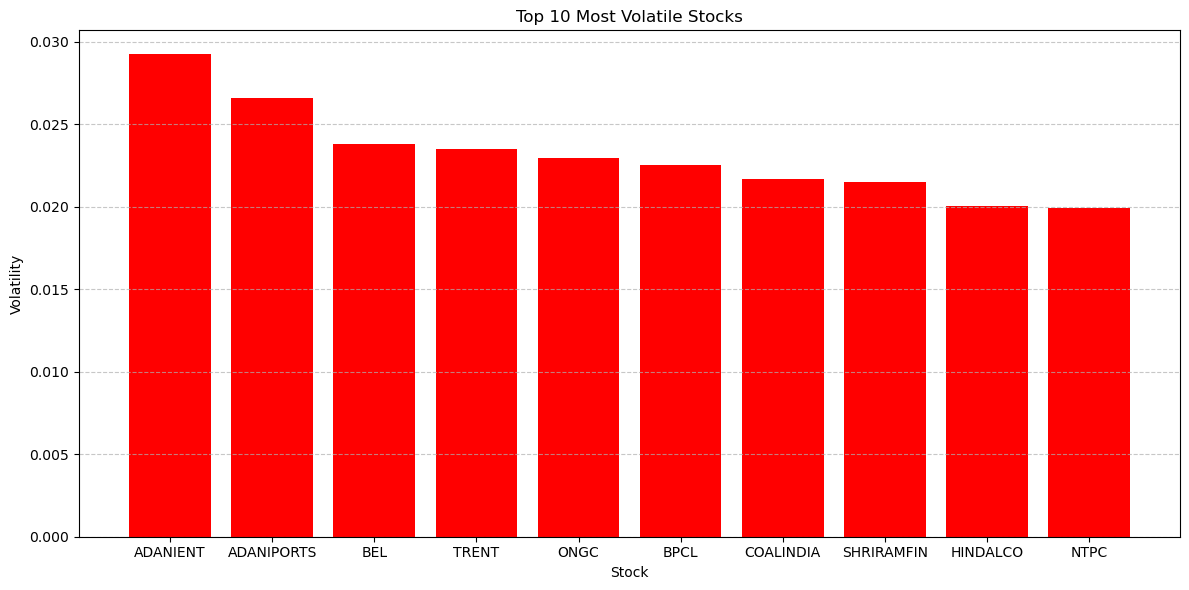

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path(r"C:\Users\santh\Documents\Python\data")
VOLATILITY_FILE = BASE_DIR / "stock_volatility_report.csv"

volatility_df = pd.read_csv(VOLATILITY_FILE)

plot_vol = volatility_df.nlargest(10, "Volatility")
plt.figure(figsize=(12, 6))
plt.bar(plot_vol["Symbol"], plot_vol["Volatility"], color="red")
plt.title("Top 10 Most Volatile Stocks")
plt.xlabel("Stock")
plt.ylabel("Volatility")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


In [5]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path(r"C:\Users\santh\Documents\Python\data")
OUTPUT_DIR = BASE_DIR / "output_csv"
CUMULATIVE_FILE = BASE_DIR / "stock_cumulative_return_report.csv"

csv_files = list(OUTPUT_DIR.glob("*.csv"))
dfs = []
for file in csv_files:
    temp = pd.read_csv(file)
    temp["Symbol"] = file.stem
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)
df["date"] = pd.to_datetime(df["date"])
df.sort_values(["Symbol", "date"], inplace=True)
df = df.groupby(["date", "Symbol"], as_index=False).agg({"close": "last"})

df["Daily_Return"] = df.groupby("Symbol")["close"].pct_change()
df["Cumulative_Return"] = (df.groupby("Symbol")["Daily_Return"].transform(lambda x: (1 + x).cumprod() - 1))
cum_df = df[["date", "Symbol", "Cumulative_Return"]].dropna()
cum_df.to_csv(CUMULATIVE_FILE, index=False)


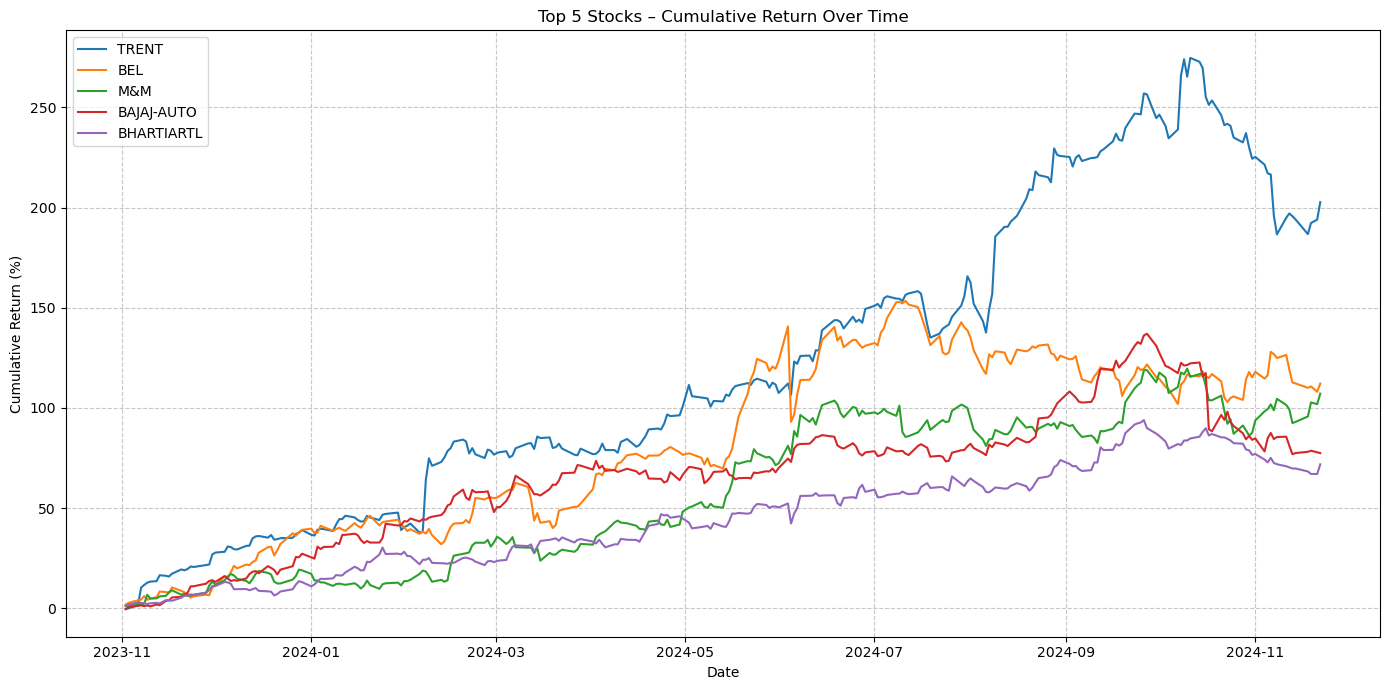

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path(r"C:\Users\santh\Documents\Python\data")
CUMULATIVE_FILE = BASE_DIR / "stock_cumulative_return_report.csv"

cum_df = pd.read_csv(CUMULATIVE_FILE)
cum_df["date"] = pd.to_datetime(cum_df["date"])

top5_symbols = (
    cum_df.groupby("Symbol")["Cumulative_Return"]
          .last()
          .nlargest(5)
          .index
)

plt.figure(figsize=(14, 7))
for symbol in top5_symbols:
    data = cum_df[cum_df["Symbol"] == symbol]
    plt.plot(data["date"], data["Cumulative_Return"] * 100, label=symbol)

plt.title("Top 5 Stocks – Cumulative Return Over Time")
plt.xlabel("Date")
plt.ylabel("Cumulative Return (%)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


In [7]:
import pandas as pd
from pathlib import Path

base_folder = r"C:\Users\santh\Documents\Python\data"
stock_folder = base_folder + "\output_csv"
output_file = base_folder + "\yearly_returns.csv"

all_files = list(Path(stock_folder).glob("*.csv"))
results = []

for file in all_files:
    stock_name = file.name.replace('.csv', '')
    
    data = pd.read_csv(file)
    data['date'] = pd.to_datetime(data['date'])
    data = data.sort_values('date')
    data['Symbol'] = stock_name
    data['Year'] = data['date'].dt.year
    
    yearly_data = data.groupby(['Symbol', 'Year'])['close'].agg(['first', 'last']).reset_index()
    yearly_data['YearlyReturn'] = ((yearly_data['last'] - yearly_data['first']) / yearly_data['first']) * 100
    
    for _, row in yearly_data.iterrows():
        results.append({ 'Symbol': row['Symbol'],'Year': row['Year'],'YearlyReturn': row['YearlyReturn']
        })

pd.DataFrame(results).to_csv(output_file, index=False)


In [8]:
import pandas as pd
from pathlib import Path

base_folder = Path(r"C:\Users\santh\Documents\Python\data")

yearly_df = pd.read_csv(base_folder / "yearly_returns.csv", encoding='latin1')
sectors_df = pd.read_csv(base_folder / "output_csv1.csv", encoding='latin1')

yearly_with_sector = yearly_df.merge(sectors_df, on='Symbol', how='left')

yearly_with_sector.to_csv(base_folder / "yearly_returns_with_sector.csv", index=False, encoding='utf-8')


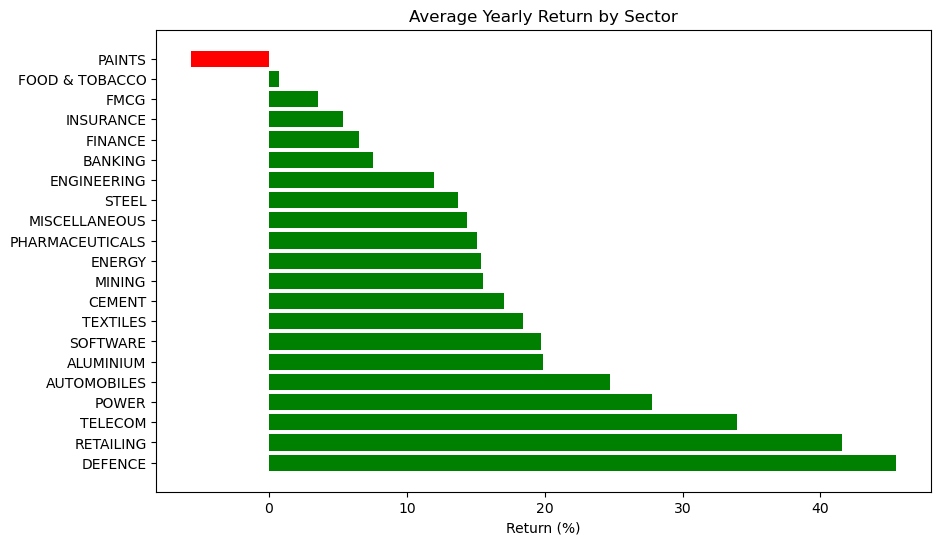

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\santh\Documents\Python\data\yearly_returns_with_sector.csv")

sector_col = "sector"
return_col = "YearlyReturn"   

sector_avg = (
    df.groupby(sector_col)[return_col]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
colors = ["green" if x > 0 else "red" for x in sector_avg]
plt.barh(sector_avg.index, sector_avg.values, color=colors)
plt.title("Average Yearly Return by Sector")
plt.xlabel("Return (%)")
plt.show()


In [12]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path(r"C:\Users\santh\Documents\Python\data")
OUTPUT_DIR = BASE_DIR / "output_csv"
CORRELATION_FILE = BASE_DIR / "stock_correlation_matrix.csv"

def generate_correlation_csv():
    csv_files = list(OUTPUT_DIR.glob("*.csv"))
    dfs = []
    for file in csv_files:
        temp = pd.read_csv(file)
        temp["Symbol"] = file.stem
        dfs.append(temp)

    df = pd.concat(dfs, ignore_index=True)

    df["date"] = pd.to_datetime(df["date"])
    df.sort_values(["Symbol", "date"], inplace=True)
    df = df.groupby(["date", "Symbol"], as_index=False).agg({"close": "last"})

    returns_wide = df.pivot(index="date", columns="Symbol", values="close").pct_change()
    corr_df = returns_wide.corr(min_periods=30)
    corr_df.to_csv(CORRELATION_FILE)
   
if __name__ == "__main__":
    generate_correlation_csv()


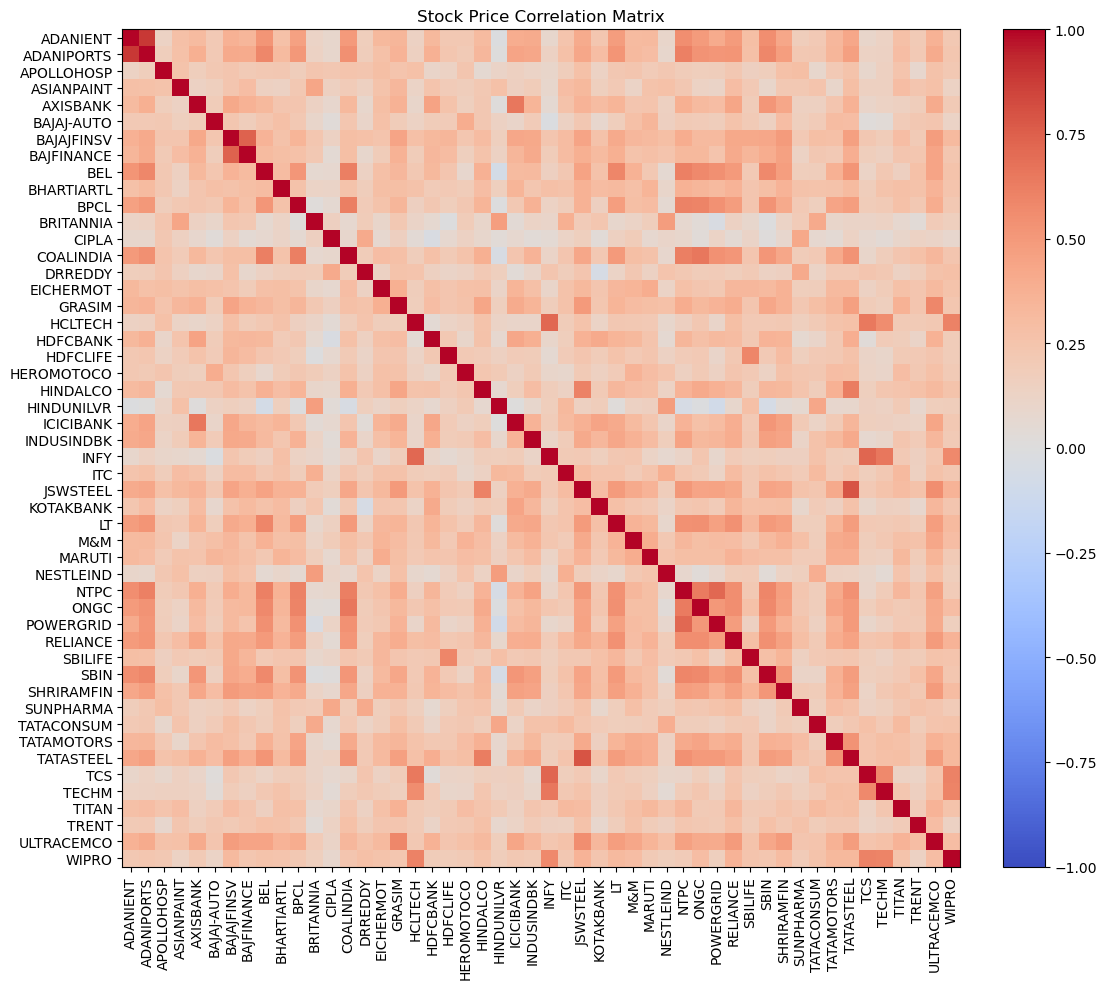

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path(r"C:\Users\santh\Documents\Python\data")
CORRELATION_FILE = BASE_DIR / "stock_correlation_matrix.csv"

corr_plot_df = pd.read_csv(CORRELATION_FILE, index_col=0)
corr_plot_df = corr_plot_df.apply(pd.to_numeric, errors="coerce")
corr_plot_df.dropna(axis=0, how="all", inplace=True)
corr_plot_df.dropna(axis=1, how="all", inplace=True)

plt.figure(figsize=(12, 10))
img = plt.imshow(corr_plot_df.values, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(img, fraction=0.046, pad=0.04)
plt.xticks(range(len(corr_plot_df.columns)), corr_plot_df.columns, rotation=90)
plt.yticks(range(len(corr_plot_df.index)), corr_plot_df.index)
plt.title("Stock Price Correlation Matrix")
plt.tight_layout()
plt.show()


In [15]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path(r"C:\Users\santh\Documents\Python\data")
OUTPUT_DIR = BASE_DIR / "output_csv"
EXPORT_FILE = BASE_DIR / "monthly_returns_report.csv"

csv_files = list(OUTPUT_DIR.glob("*.csv"))
dfs = []
for file in csv_files:
    temp = pd.read_csv(file)
    temp['Symbol'] = file.stem
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)
df['date'] = pd.to_datetime(df['date'])
df.sort_values(['Symbol', 'date'], inplace=True)

monthly_df = ( df.groupby(['Symbol', pd.Grouper(key='date', freq='ME')])['close'].last() .reset_index().rename(columns={'date': 'Month'}))

monthly_df['Returns'] = (monthly_df.groupby('Symbol')['close'] .pct_change() * 100)

monthly_df.dropna(inplace=True)
monthly_df.to_csv(EXPORT_FILE, index=False)


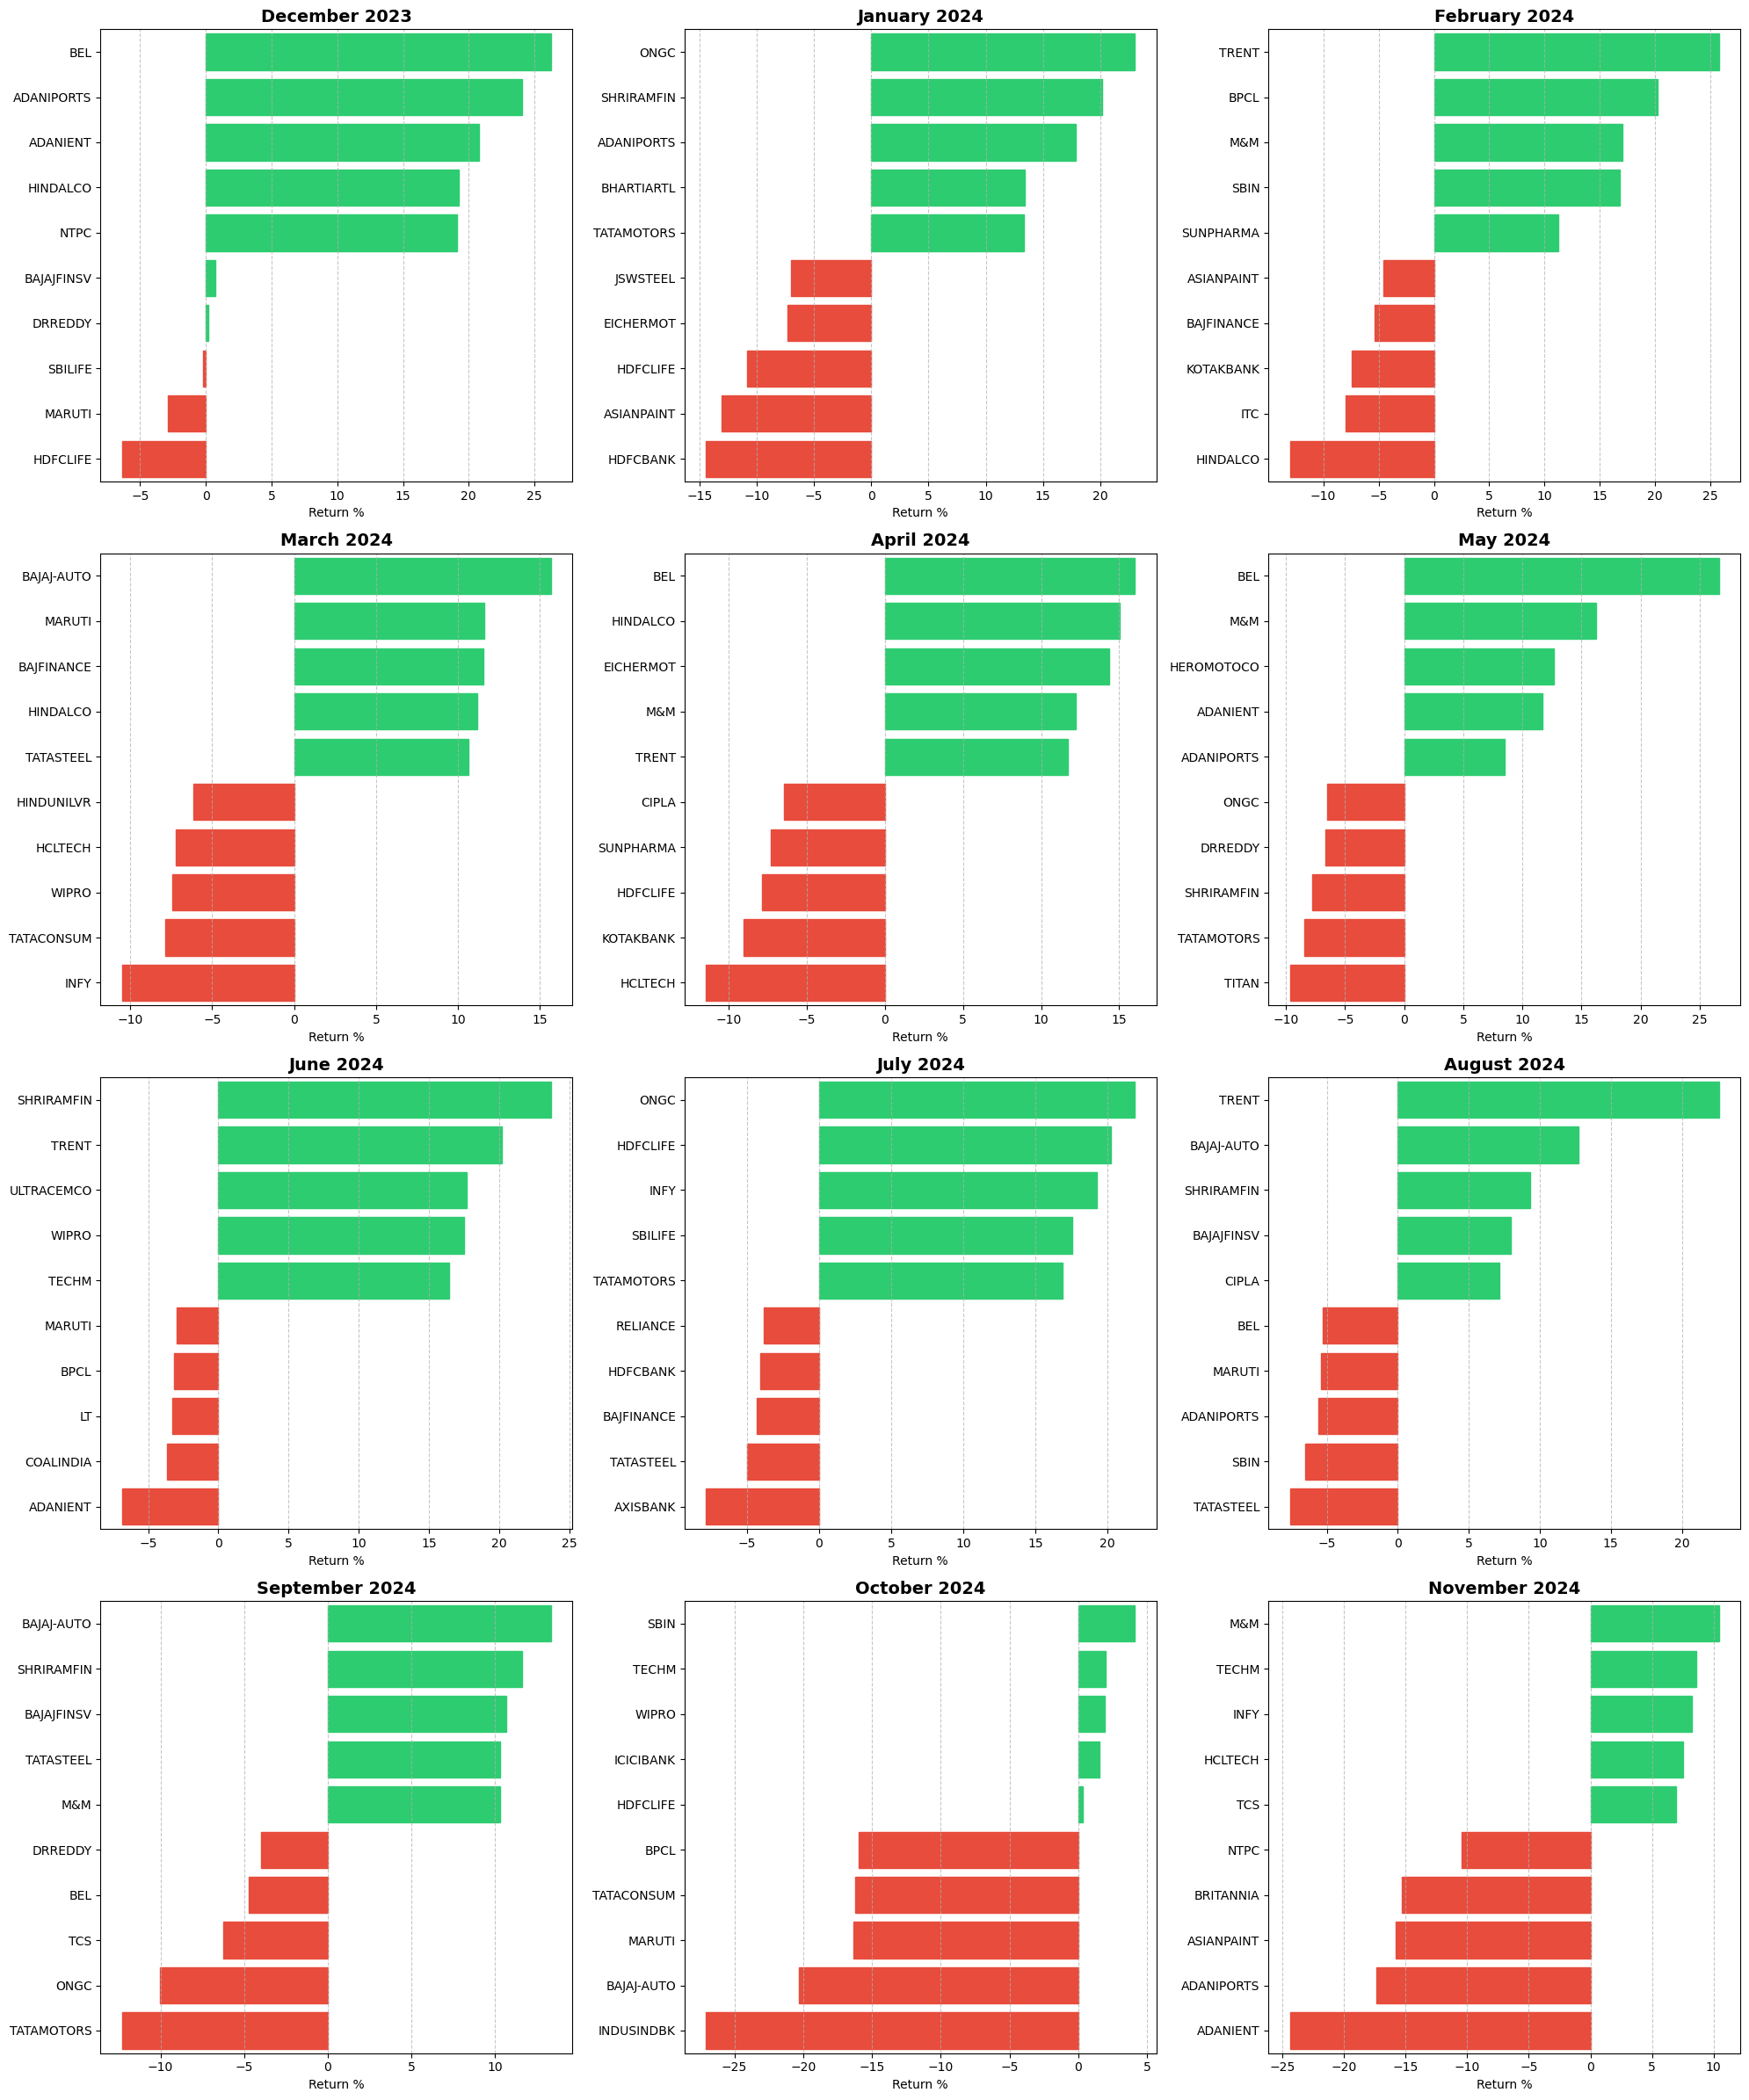

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

BASE_DIR = Path(r"C:\Users\santh\Documents\Python\data")
EXPORT_FILE = BASE_DIR / "monthly_returns_report.csv"

monthly_df = pd.read_csv(EXPORT_FILE)
monthly_df['Month'] = pd.to_datetime(monthly_df['Month'])

months = sorted(monthly_df['Month'].unique())[:12]
fig, axes = plt.subplots(4, 3, figsize=(20, 24))
axes = axes.flatten()

for i, month in enumerate(months):
    month_data = monthly_df[monthly_df['Month'] == month]
    top = month_data.nlargest(5, 'Returns')
    bottom = month_data.nsmallest(5, 'Returns')
    combined = pd.concat([top, bottom]).sort_values('Returns', ascending=False)

    sns.barplot(data=combined, x='Returns', y='Symbol', ax=axes[i], palette=None)
    
    for bar in axes[i].patches:
        val = bar.get_width()
        bar.set_color('#2ecc71' if val > 0 else '#e74c3c')

    axes[i].set_title(month.strftime('%B %Y'), fontweight='bold', fontsize=14)
    axes[i].set_xlabel('Return %')
    axes[i].set_ylabel('')
    axes[i].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
